In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder

from mlxtend.frequent_patterns import (
    apriori,
    association_rules
)

In [6]:
df = pd.read_csv(
    "../dataset/GroceryStoreDataset.csv"
)

df.head()

,TransactionID,Items
0,1,"TELUR,SAUS,MIE INSTAN"
1,2,"SUSU,KEJU,ROTI,KRIMER"
2,3,"BISKUIT,GULA,COKLAT,AIR MINERAL,TEH"
3,4,"PASTA GIGI,SAUS,SHAMPOO,SABUN"
4,5,"PASTA GIGI,SHAMPOO,SABUN,BERAS,MIE INSTAN,KRIMER"


In [7]:
transactions = []

for item in df['Items']:

    products = [
        x.strip().upper()
        for x in item.split(',')
    ]

    transactions.append(products)

transactions[:5]

[['TELUR', 'SAUS', 'MIE INSTAN'],
 ['SUSU', 'KEJU', 'ROTI', 'KRIMER'],
 ['BISKUIT', 'GULA', 'COKLAT', 'AIR MINERAL', 'TEH'],
 ['PASTA GIGI', 'SAUS', 'SHAMPOO', 'SABUN'],
 ['PASTA GIGI', 'SHAMPOO', 'SABUN', 'BERAS', 'MIE INSTAN', 'KRIMER']]

In [8]:
te = TransactionEncoder()

te_array = (
    te.fit(transactions)
      .transform(transactions)
)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

basket.head()

,AIR MINERAL,BERAS,BISKUIT,COKLAT,GULA,KEJU,KOPI,KRIMER,MIE INSTAN,MINYAK,...,ROTI,SABUN,SAUS,SELAI,SEREAL,SHAMPOO,SNACK,SUSU,TEH,TELUR
0,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
1,False,False,False,False,False,True,False,True,False,False,...,True,False,False,False,False,False,False,True,False,False
2,True,False,True,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,True,False,False,True,False,False,False,False
4,False,True,False,False,False,False,False,True,True,False,...,False,True,False,False,False,True,False,False,False,False


In [9]:
support_values = [
    0.01,
    0.02,
    0.03,
    0.05,
    0.1
]

In [10]:
results = []

for support in support_values:

    frequent_itemsets = apriori(
        basket,
        min_support=support,
        use_colnames=True
    )

    if frequent_itemsets.empty:

        results.append({
            "support": support,
            "rules": 0
        })

        continue

    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=0.2
    )

    results.append({
        "support": support,
        "rules": len(rules)
    })

In [11]:
result_df = pd.DataFrame(
    results
)

result_df

,support,rules
0,0.01,1124
1,0.02,233
2,0.03,177
3,0.05,130
4,0.10,28


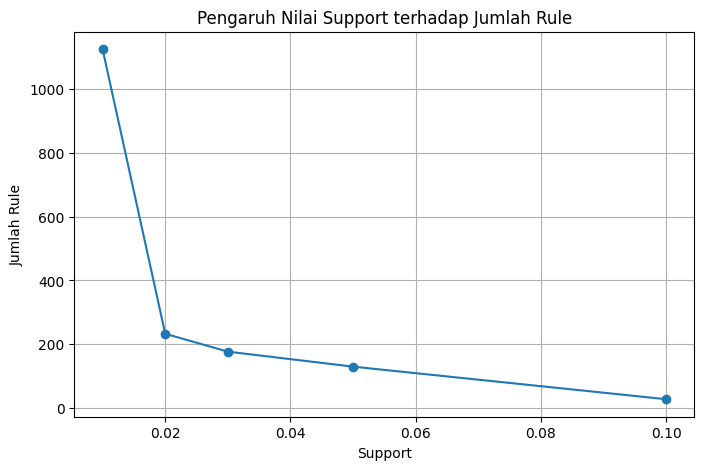

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    result_df["support"],
    result_df["rules"],
    marker="o"
)

plt.title(
    "Pengaruh Nilai Support terhadap Jumlah Rule"
)

plt.xlabel("Support")

plt.ylabel("Jumlah Rule")

plt.grid(True)

plt.show()